# Salary Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [88]:
sns.set_style("whitegrid")

In [2]:
df=pd.read_csv("Salary_Dataset_DSL.csv")
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [4]:
df.shape

(22770, 8)

In [5]:
df.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [6]:
df.describe()

,Rating,Salary,Salaries Reported
count,22770.000000,2.277000e+04,22770.000000
mean,3.918213,6.953872e+05,1.855775
std,0.519675,8.843990e+05,6.823668
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,9.000000e+05,1.000000
max,5.000000,9.000000e+07,361.000000


In [8]:
df.describe(include="all")

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22769,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


In [11]:
df=df.drop_duplicates()
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


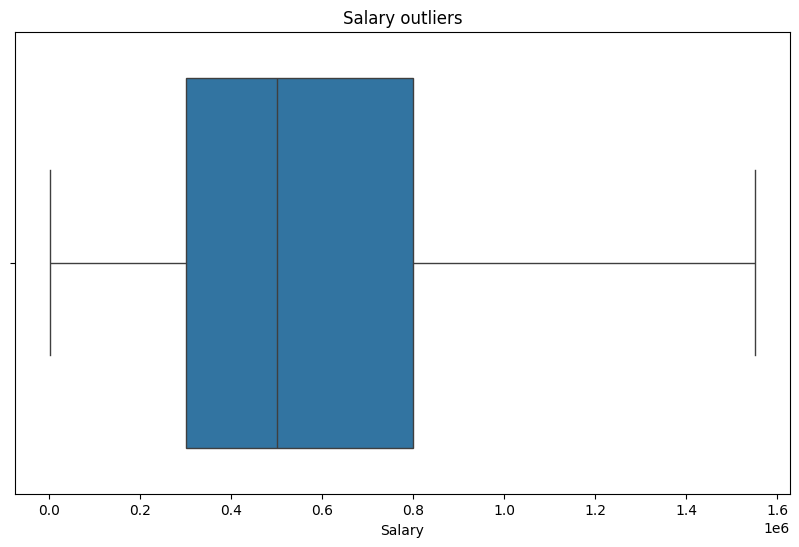

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Salary"])
plt.title("Salary outliers")
plt.show()

In [40]:
# Calculate Q1 and Q3
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filter dataframe
df = df[(df["Salary"] >= lower_limit) & (df["Salary"] <= upper_limit)]

df.shape

(21014, 8)

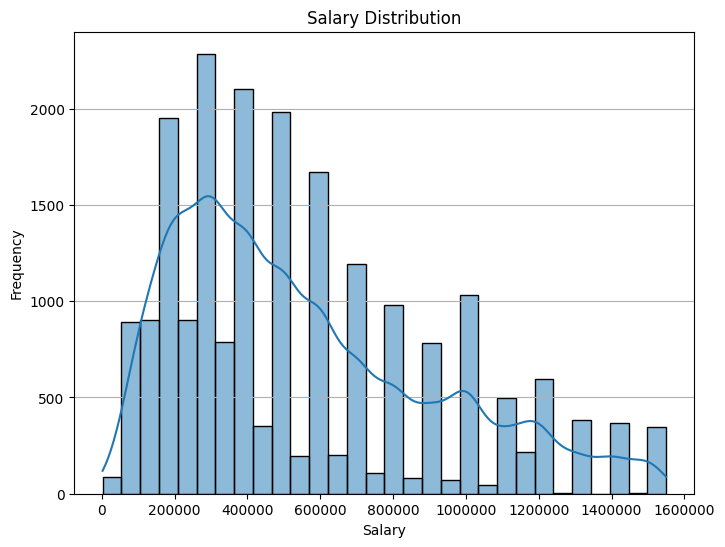

In [42]:
plt.figure(figsize=(8,6))
sns.histplot(df["Salary"], bins=30, kde=True)
plt.ticklabel_format(style="plain",axis="x")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


# Q-1. which job Roles Have highest Average salary?

In [25]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [43]:
job_salary = df.groupby('Job Roles')['Salary'].mean()\
                .sort_values(ascending=False)\
                .reset_index()

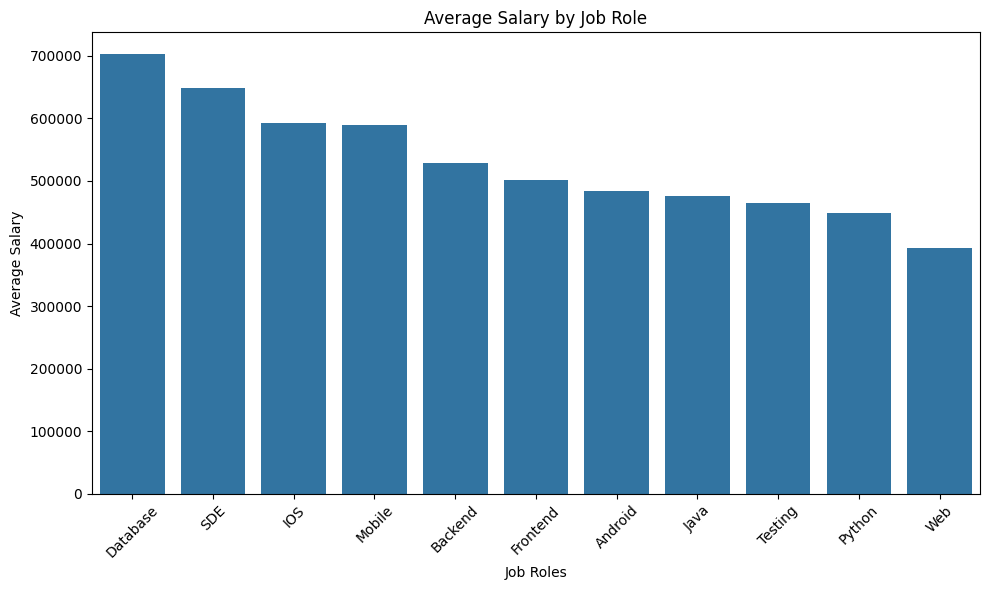

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(data=job_salary, x='Job Roles', y='Salary')
plt.xticks(rotation=45)
plt.title("Average Salary by Job Role")
plt.xlabel("Job Roles")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()


In [45]:
city_salary = df.groupby('Location')['Salary'].mean()\
                .sort_values(ascending=False)\
                .reset_index()
city_salary

,Location,Salary
0,Mumbai,702195.874214
1,Bangalore,568223.271851
2,Jaipur,566153.846154
3,Pune,562387.138833
4,New Delhi,542717.057751
5,Hyderabad,538809.567450
6,Kolkata,532604.938272
7,Kerala,514965.735849
8,Chennai,505102.446337
9,Madhya Pradesh,497530.378378


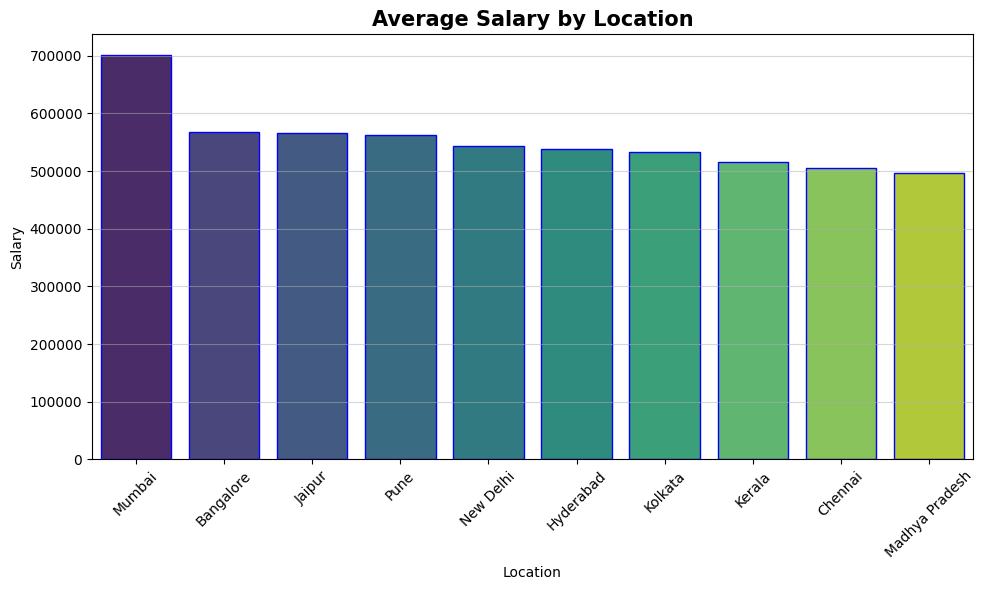

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=city_salary,
    x='Location',
    y='Salary',
    hue='Location',     
    palette='viridis',
    legend=False,
    edgecolor="blue"       
)
plt.grid(axis='y',alpha=0.5)
plt.xticks(rotation=45)
plt.title("Average Salary by Location",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.show()


# Q-3.Name those 5 companies located in new delhi with ratings of 5 ,offring highest and lowest salaries.

In [64]:
df1=df[(df["Location"]=="New Delhi") & (df["Rating"]==5)].sort_values(by="Salary",ascending=False)

In [65]:
df1

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
1888,5.0,Trillbit,Android Developer,1500000,1,New Delhi,Full Time,Android
6750,5.0,Hapramp,Front End Developer,1500000,1,New Delhi,Full Time,Frontend
17488,5.0,The Art of Mike Mignola,Software Development Engineer,1500000,1,New Delhi,Full Time,SDE
8284,5.0,Silicon Valley Recycling,Senior IOS Developer,1400000,1,New Delhi,Full Time,IOS
17351,5.0,Parth Universal,Software Development Engineer,1300000,1,New Delhi,Full Time,SDE
...,...,...,...,...,...,...,...,...
8008,5.0,Rabbler,IOS Developer Contractor,100000,1,New Delhi,Contractor,IOS
1969,5.0,WorkingNation,Android Developer - Intern,84000,1,New Delhi,Intern,Android
2334,5.0,Hopin (India),Android Developer - Intern,60000,1,New Delhi,Intern,Android
17524,5.0,Star Catalysts,Software Development Engineer - Intern,60000,1,New Delhi,Intern,SDE


In [68]:
list(df['Company Name'].head())

['Sasken',
 'Advanced Millennium Technologies',
 'Unacademy',
 'SnapBizz Cloudtech',
 'Appoids Tech Solutions']

In [69]:
list(df['Company Name'].tail())

['Expert Solutions',
 'Nextgen Innovation Labs',
 'Fresher',
 'Accenture',
 'Thomson Reuters']

# Q-4. which job Title has the highest number of salary reported?

In [74]:
df.groupby("Job Title")['Salaries Reported'].count().sort_values(ascending=False)

Job Title
Software Development Engineer                             2137
Android Developer                                         1983
Software Development Engineer (SDE)                       1477
Front End Developer                                       1360
Test Engineer                                             1290
                                                          ... 
TECHNICAL LEAD - Software Development Engineer In Test       1
Team Lead/Senior Java Developer                              1
Tech Lead- Android Applications Developer                    1
Techlead Java                                                1
Technical Lead - Java/J2EE                                   1
Name: Salaries Reported, Length: 981, dtype: int64

# Q-5. which 10 companies provide the highest average salary ,when at least 20 employees have Reported their Salaries?

In [76]:
# 1. Group by company and get count + average salary
salary_stats = df.groupby('Company Name')['Salary'].agg(
    count_reported = 'count',
    avg_salary = 'mean'
).reset_index()

# 2. Filter companies with at least 20 reported salaries
salary_filtered = salary_stats[salary_stats['count_reported'] >= 20]

# 3. Sort by highest average salary
top_10_salary = salary_filtered.sort_values(by='avg_salary', ascending=False).head(10)

# 4. Display result
top_10_salary


,Company Name,count_reported,avg_salary
4520,J.P. Morgan,20,970000.000000
5441,Mastercard,22,967090.909091
2999,Expedia Group,21,927238.095238
6307,OYO,23,908173.913043
3303,Freshworks,20,843200.000000
7749,Samsung Electronics,21,828571.428571
5584,Microsoft,60,821810.666667
6448,Oracle,59,809694.915254
1849,Cisco Systems,29,792137.931034
9660,Verizon,24,786666.666667


# Q-5 check and show the relationship between Ratings and Salaries.

In [77]:
df['Rating'].corr(df['Salary'])

np.float64(0.02477162838343562)

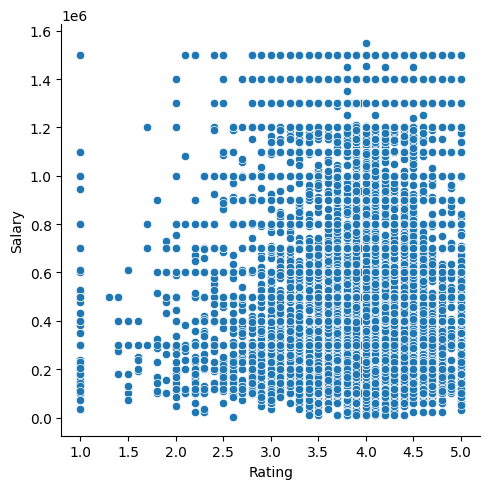

In [81]:
# Ensure numeric columns
df['Salary'] = df['Salary'].replace('[\$,]', '', regex=True).astype(float)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Scatter plot
sns.relplot(x='Rating', y='Salary', data=df)
plt.show()

<Axes: >

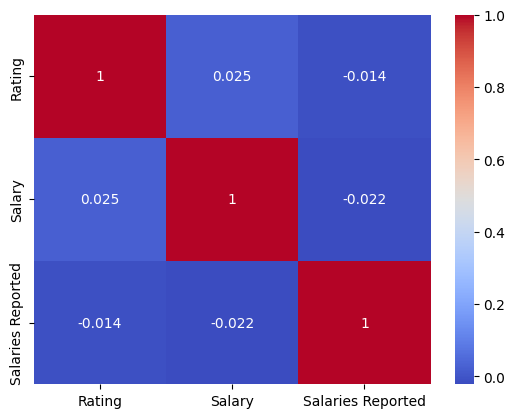

In [80]:
numeric_df = df.select_dtypes(include='number')  # select numeric columns only
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")


# Q-6.Does Employement status affect the salary?

In [83]:
df['Employment Status'].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [84]:
df['Employment Status'].value_counts()

Employment Status
Full Time     18379
Intern         2089
Contractor      513
Trainee          33
Name: count, dtype: int64

In [85]:
df.groupby('Employment Status')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,513.0,501507.586745,315663.813209,12000.0,300000.0,400000.0,600000.0,1500000.0
Full Time,18379.0,579305.536101,358065.460032,8448.0,300000.0,500000.0,800000.0,1550000.0
Intern,2089.0,338353.991383,264180.887035,2112.0,144000.0,264000.0,456000.0,1500000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


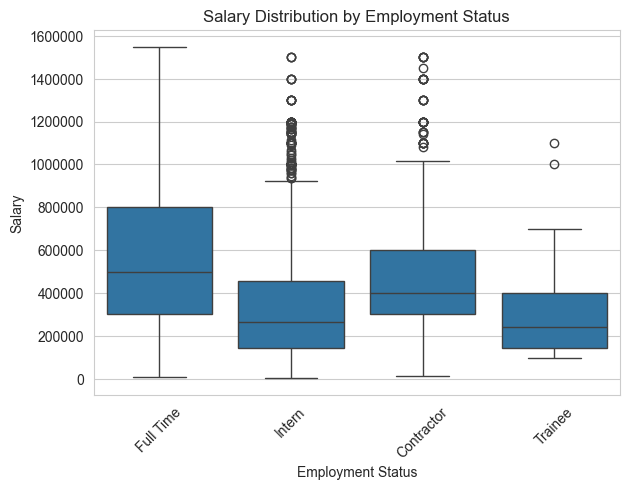

In [91]:
sns.boxplot(x='Employment Status', y='Salary', data=df)
plt.xticks(rotation=45)  # rotate x labels if needed
plt.ticklabel_format(style="plain",axis='y')
plt.tight_layout()
plt.title('Salary Distribution by Employment Status')
plt.show()

# Q-7. which job roles are most common?



In [92]:
df['Job Roles'].value_counts()

Job Roles
SDE         7245
Android     2812
Frontend    2034
Java        1778
Testing     1710
IOS         1524
Backend     1049
Web          988
Python       929
Database     734
Mobile       211
Name: count, dtype: int64

In [99]:
top_roles = df['Job Roles'].value_counts().head(10).reset_index()



In [100]:
top_roles.columns = ['Job Roles', 'Count']


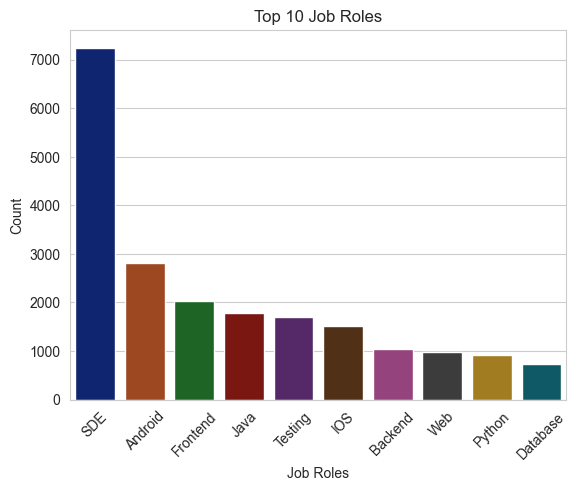

In [105]:
sns.set_style("whitegrid")
sns.barplot(data=top_roles, x='Job Roles', y='Count',palette='dark',hue='Job Roles')
plt.xticks(rotation=45)
plt.title("Top 10 Job Roles")
plt.show()

# Q-9. How does average salary change as company rating increase ?

In [106]:
avg_salary_by_rating = df.groupby('Rating')['Salary'].mean().reset_index()


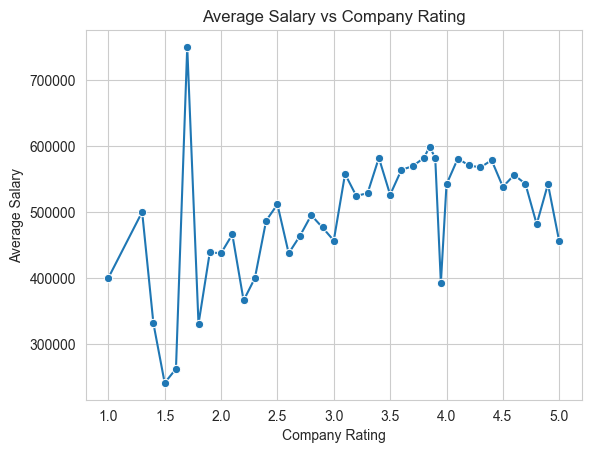

In [107]:
sns.set_style("whitegrid")
sns.lineplot(data=avg_salary_by_rating, x='Rating', y='Salary', marker='o')
plt.title("Average Salary vs Company Rating")
plt.xlabel("Company Rating")
plt.ylabel("Average Salary")
plt.show()

In [141]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 🔢 KPI Calculations
total_companies = df['Company Name'].nunique()
total_employees = df['Salaries Reported'].sum()
avg_salary = df['Salary'].mean()
highest_paying_job = df.groupby('Job Roles')['Salary'].mean().idxmax()

# Create 3x2 Subplot Layout
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "Average Salary by Job Role",
        "Average Salary by Location",
        "Top 10 Job Roles",
        "Average Salary vs Company Rating",
        "Salary Distribution by Employment Status",
        ""  # Empty space
    ),
    specs=[[{"type":"bar"}, {"type":"bar"}],
           [{"type":"bar"}, {"type":"scatter"}],
           [{"type":"box"}, None]]
)

# 1️⃣ Average Salary by Job Role
fig.add_trace(
    go.Bar(x=job_salary['Job Roles'], y=job_salary['Salary'], marker_color='teal'),
    row=1, col=1
)

# 2️⃣ Average Salary by Location
fig.add_trace(
    go.Bar(x=city_salary['Location'], y=city_salary['Salary'], marker_color='orange'),
    row=1, col=2
)

# 3️⃣ Top 10 Job Roles
fig.add_trace(
    go.Bar(x=top_roles['Job Roles'], y=top_roles['Count'], marker_color='purple'),
    row=2, col=1
)

# 4️⃣ Average Salary vs Company Rating
fig.add_trace(
    go.Scatter(x=avg_salary_by_rating['Rating'], y=avg_salary_by_rating['Salary'],
               mode='lines+markers', line=dict(color='blue')),
    row=2, col=2
)

# 5️⃣ Salary Distribution by Employment Status
fig.add_trace(
    go.Box(x=df['Employment Status'], y=df['Salary'], marker_color='green'),
    row=3, col=1
)

# 🏷 KPI Cards (Top Section)
fig.add_annotation(
    text=f"<b>Total Companies:</b> {total_companies}",
    x=0.02, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)
fig.add_annotation(
    text=f"<b>Total Employees:</b> {total_employees:,}",
    x=0.26, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)
fig.add_annotation(
    text=f"<b>Average Salary:</b> ₹{avg_salary:,.0f}",
    x=0.62, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)
fig.add_annotation(
    text=f"<b>Highest Paying Role:</b> {highest_paying_job}",
    x=1.03, y=1.07, xref="paper", yref="paper",
    showarrow=False, font=dict(size=14)
)

# Layout Adjustments
fig.update_layout(
    height=1200,
    width=1000,
    title={
        'text': "📊 Salary Analysis Dashboard",
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=False,
    margin=dict(t=160)
)

fig.show()
